# 🧠 Memory Sparse Attention (MSA) — Applications illustrées

> **Basé sur** : *MSA: Memory Sparse Attention for Efficient End-to-End Memory Model Scaling to 100M Tokens* (Chen et al., 2025)

Ce notebook illustre les concepts clés et les applications potentielles de MSA à travers des simulations et visualisations interactives.

---

## Table des matières

1. **Le fossé mémoriel** — Pourquoi 100M tokens ?
2. **Attention dense vs sparse** — Analyse de complexité
3. **Mécanisme de routage Top-k** — Simulation de la sélection documentaire
4. **Document-wise RoPE** — Extrapolation positionnelle
5. **Compression KV cache** — Impact du pooling
6. **Memory Interleave** — Raisonnement multi-hop
7. **Scalabilité** — Reproduction de la courbe de dégradation
8. **Applications concrètes** — Scénarios d'usage réels


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.special import softmax
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'text.color': '#e6edf3',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'axes.edgecolor': '#30363d',
    'grid.color': '#21262d',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

COLORS = {
    'msa': '#58a6ff',
    'rag': '#f97583',
    'dense': '#d2a8ff',
    'linear': '#7ee787',
    'accent': '#ffa657',
    'bg': '#0d1117',
    'grid': '#21262d',
    'text': '#e6edf3',
    'muted': '#8b949e'
}

print("✅ Environnement prêt — Let's explore MSA!")


✅ Environnement prêt — Let's explore MSA!


---
## 1. 🧬 Le fossé mémoriel humain-machine

La mémoire humaine fonctionnelle est estimée à ~10⁹ bits (Landauer, 1986). En supposant 3-5 bits/token, cela correspond à **200-300M tokens**. Les LLM actuels plafonnent à 1M tokens effectifs.


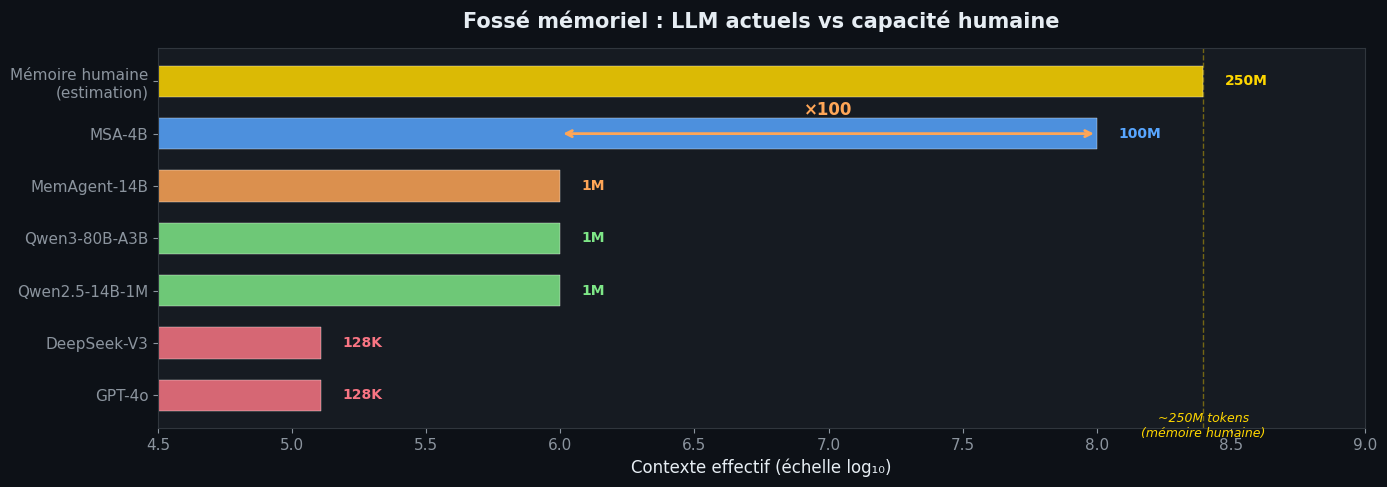

📊 MSA comble le fossé de 2 ordres de grandeur entre les LLM conventionnels
   et la capacité estimée de la mémoire humaine.


In [2]:
fig, ax = plt.subplots(figsize=(14, 5))

systems = [
    ('GPT-4o', 128_000, COLORS['rag']),
    ('DeepSeek-V3', 128_000, COLORS['rag']),
    ('Qwen2.5-14B-1M', 1_000_000, COLORS['linear']),
    ('Qwen3-80B-A3B', 1_000_000, COLORS['linear']),
    ('MemAgent-14B', 1_000_000, COLORS['accent']),
    ('MSA-4B', 100_000_000, COLORS['msa']),
    ('Mémoire humaine\n(estimation)', 250_000_000, '#ffd700'),
]

y_pos = np.arange(len(systems))
for i, (name, tokens, color) in enumerate(systems):
    bar = ax.barh(i, np.log10(tokens), color=color, alpha=0.85, height=0.6,
                  edgecolor='white', linewidth=0.3)
    label = f"{tokens/1e6:.0f}M" if tokens >= 1e6 else f"{tokens/1e3:.0f}K"
    ax.text(np.log10(tokens) + 0.08, i, label, va='center', fontsize=10,
            color=color, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([s[0] for s in systems], fontsize=11)
ax.set_xlabel('Contexte effectif (échelle log₁₀)', fontsize=12)
ax.set_title('Fossé mémoriel : LLM actuels vs capacité humaine', fontsize=15, pad=15)
ax.set_xlim(4.5, 9)
ax.axvline(x=np.log10(250_000_000), color='#ffd700', linestyle='--', alpha=0.4, linewidth=1)
ax.text(np.log10(250_000_000), -0.8, '~250M tokens\n(mémoire humaine)',
        ha='center', fontsize=9, color='#ffd700', style='italic')

# Annotations
ax.annotate('', xy=(np.log10(100_000_000), 5), xytext=(np.log10(1_000_000), 5),
            arrowprops=dict(arrowstyle='<->', color=COLORS['accent'], lw=2))
ax.text(np.log10(10_000_000), 5.35, '×100', ha='center', fontsize=12,
        color=COLORS['accent'], fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 MSA comble le fossé de 2 ordres de grandeur entre les LLM conventionnels")
print("   et la capacité estimée de la mémoire humaine.")


---
## 2. ⚡ Complexité : Attention dense vs MSA

L'attention dense standard est en O(L²), ce qui rend 100M tokens totalement impraticable.
MSA atteint une complexité **linéaire O(L)** par requête grâce au routage sparse.


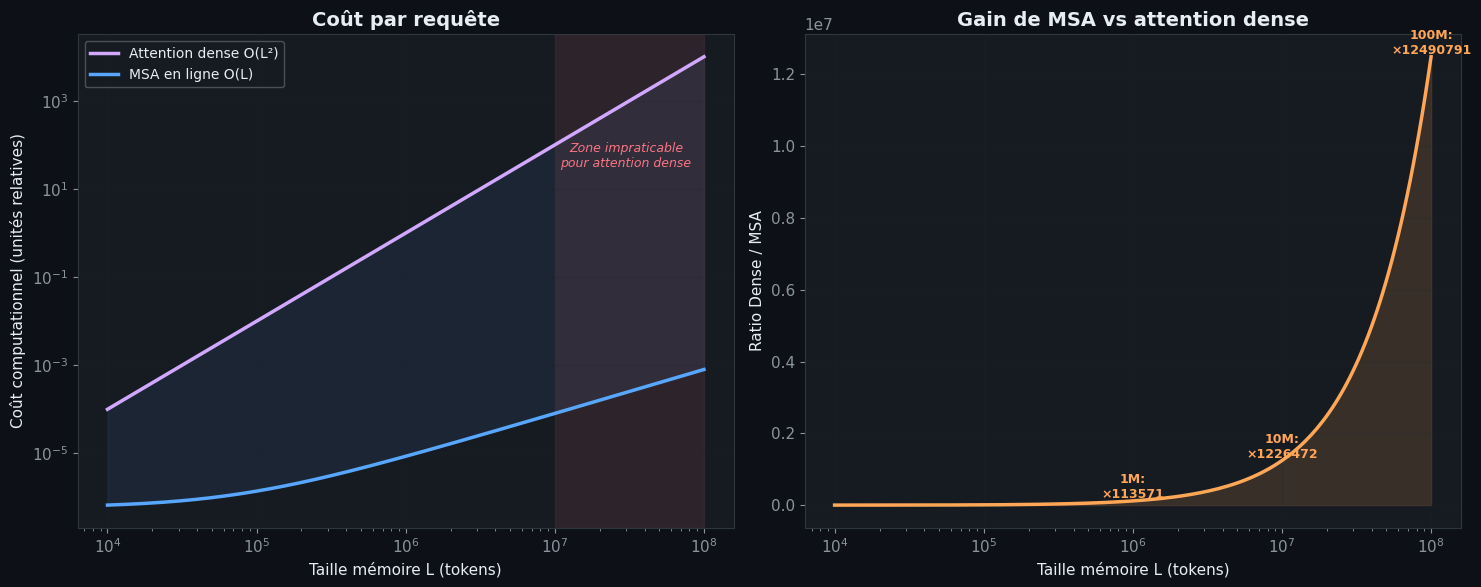

💡 À 100M tokens, MSA est ~12490791× moins coûteux que l'attention dense par requête.
   Le pré-encodage offline O(LG) est amorti sur toutes les requêtes servies.


In [3]:
L_values = np.logspace(4, 8, 200)  # 10K -> 100M tokens
M = 512    # query length
G = 1024   # avg doc length
k = 16     # top-k
P = 64     # pooling size

# Complexités (en unités arbitraires, normalisées)
dense_attn = L_values ** 2                                    # O(L²)
linear_attn = L_values * G                                     # O(LG) mais état fixe → dégradation
msa_offline = L_values * G                                     # O(LG) one-time
msa_online = M * L_values / P + (M + k * G / P) ** 2          # O(L) per query

# Normalisation pour la lisibilité
norm = 1e12
dense_attn /= norm
msa_online /= norm
msa_offline /= norm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# — Plot 1 : Coût par requête —
ax1.loglog(L_values, dense_attn, color=COLORS['dense'], lw=2.5, label='Attention dense O(L²)')
ax1.loglog(L_values, msa_online, color=COLORS['msa'], lw=2.5, label='MSA en ligne O(L)')
ax1.fill_between(L_values, msa_online, dense_attn, alpha=0.08, color=COLORS['msa'])

ax1.set_xlabel('Taille mémoire L (tokens)')
ax1.set_ylabel('Coût computationnel (unités relatives)')
ax1.set_title('Coût par requête')
ax1.legend(fontsize=10, framealpha=0.3)
ax1.grid(True, alpha=0.2)

# Zone "impraticable"
ax1.axvspan(1e7, 1e8, alpha=0.1, color=COLORS['rag'])
ax1.text(3e7, dense_attn[150] * 0.3, 'Zone impraticable\npour attention dense',
         ha='center', fontsize=9, color=COLORS['rag'], style='italic')

# — Plot 2 : Ratio d'économie —
speedup = dense_attn / msa_online
ax2.semilogx(L_values, speedup, color=COLORS['accent'], lw=2.5)
ax2.fill_between(L_values, 1, speedup, alpha=0.15, color=COLORS['accent'])
ax2.set_xlabel('Taille mémoire L (tokens)')
ax2.set_ylabel('Ratio Dense / MSA')
ax2.set_title('Gain de MSA vs attention dense')
ax2.grid(True, alpha=0.2)

# Annotations
for target, label in [(1e6, '1M'), (1e7, '10M'), (1e8, '100M')]:
    idx = np.argmin(np.abs(L_values - target))
    ratio = speedup[idx]
    ax2.annotate(f'{label}:\n×{ratio:.0f}', xy=(target, ratio),
                fontsize=9, ha='center', va='bottom',
                color=COLORS['accent'], fontweight='bold')

plt.tight_layout()
plt.show()

print(f"💡 À 100M tokens, MSA est ~{speedup[-1]:.0f}× moins coûteux que l'attention dense par requête.")
print(f"   Le pré-encodage offline O(LG) est amorti sur toutes les requêtes servies.")


---
## 3. 🎯 Simulation du routage Top-k

Le cœur de MSA : un projecteur de routage (Q^R, K^R) séparé des clés d'attention.
Simulons comment le modèle sélectionne les documents pertinents parmi des milliers.


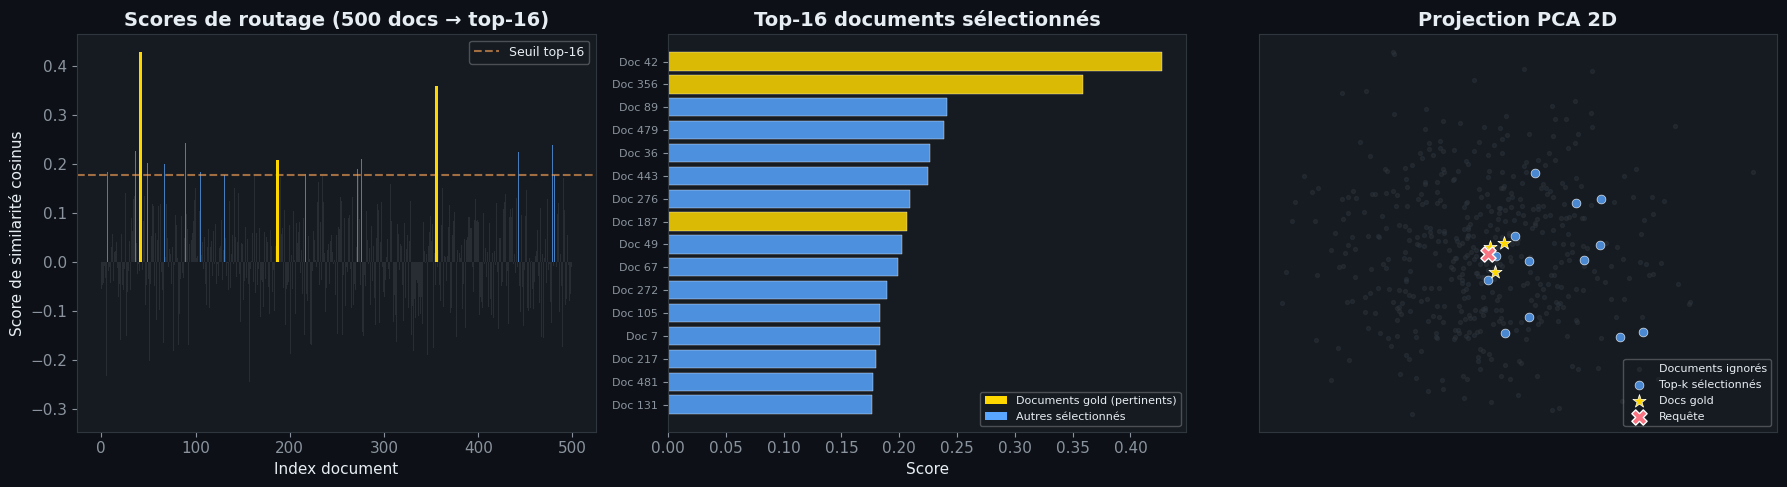

✅ 3/3 documents gold retrouvés dans le top-16
   Taux de sparsité : 96.8% des documents ignorés → économie massive


In [4]:
np.random.seed(42)

# Simulation : 500 documents, dimension 128
n_docs = 500
dim = 128
k_topk = 16

# Créer des embeddings documentaires (K^R compressé)
doc_embeddings = np.random.randn(n_docs, dim).astype(np.float32)

# Créer 3 documents "gold" (pertinents) avec un signal spécifique
query_direction = np.random.randn(dim).astype(np.float32)
query_direction /= np.linalg.norm(query_direction)

gold_indices = [42, 187, 356]
for idx in gold_indices:
    noise = np.random.randn(dim) * 0.3
    doc_embeddings[idx] = query_direction * 3.0 + noise

# Requête
query_embedding = query_direction + np.random.randn(dim) * 0.15
query_embedding /= np.linalg.norm(query_embedding)

# Calcul des scores de similarité cosinus
scores = np.array([
    1 - cosine(query_embedding, doc_embeddings[i] / (np.linalg.norm(doc_embeddings[i]) + 1e-8))
    for i in range(n_docs)
])

# Top-k selection
topk_indices = np.argsort(scores)[-k_topk:][::-1]

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 : Distribution des scores
ax = axes[0]
colors_bar = [COLORS['msa'] if i in topk_indices else '#30363d' for i in range(n_docs)]
gold_mask = [i in gold_indices for i in range(n_docs)]
ax.bar(range(n_docs), scores, color=colors_bar, width=1.0, alpha=0.7)
for gi in gold_indices:
    ax.bar(gi, scores[gi], color='#ffd700', width=3, alpha=1.0, zorder=5)
ax.axhline(y=scores[topk_indices[-1]], color=COLORS['accent'], linestyle='--', alpha=0.6, label=f'Seuil top-{k_topk}')
ax.set_xlabel('Index document')
ax.set_ylabel('Score de similarité cosinus')
ax.set_title(f'Scores de routage (500 docs → top-{k_topk})')
ax.legend(fontsize=9, framealpha=0.3)

# Plot 2 : Zoom sur les top-k
ax = axes[1]
sorted_topk = sorted(topk_indices, key=lambda i: scores[i], reverse=True)
bar_colors = ['#ffd700' if i in gold_indices else COLORS['msa'] for i in sorted_topk]
bars = ax.barh(range(k_topk), [scores[i] for i in sorted_topk],
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(k_topk))
ax.set_yticklabels([f'Doc {i}' for i in sorted_topk], fontsize=8)
ax.set_xlabel('Score')
ax.set_title(f'Top-{k_topk} documents sélectionnés')
ax.invert_yaxis()

legend_elements = [
    mpatches.Patch(facecolor='#ffd700', label='Documents gold (pertinents)'),
    mpatches.Patch(facecolor=COLORS['msa'], label='Autres sélectionnés')
]
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.3)

# Plot 3 : Projection 2D (t-SNE simplifié via PCA)
ax = axes[2]
from numpy.linalg import svd
all_emb = np.vstack([doc_embeddings, query_embedding.reshape(1, -1)])
centered = all_emb - all_emb.mean(axis=0)
U, S, Vt = svd(centered, full_matrices=False)
proj = U[:, :2] * S[:2]

doc_proj = proj[:-1]
query_proj = proj[-1]

# Background docs
mask_other = np.ones(n_docs, dtype=bool)
mask_other[list(topk_indices)] = False
ax.scatter(doc_proj[mask_other, 0], doc_proj[mask_other, 1],
           c='#30363d', s=8, alpha=0.4, label='Documents ignorés')
# Top-k
mask_topk = np.zeros(n_docs, dtype=bool)
mask_topk[list(topk_indices)] = True
mask_topk[gold_indices] = False
ax.scatter(doc_proj[mask_topk, 0], doc_proj[mask_topk, 1],
           c=COLORS['msa'], s=40, alpha=0.8, label='Top-k sélectionnés', edgecolors='white', linewidth=0.5)
# Gold
ax.scatter(doc_proj[gold_indices, 0], doc_proj[gold_indices, 1],
           c='#ffd700', s=100, alpha=1, marker='*', label='Docs gold', edgecolors='white', linewidth=0.5, zorder=10)
# Query
ax.scatter(query_proj[0], query_proj[1],
           c=COLORS['rag'], s=120, marker='X', label='Requête', edgecolors='white', linewidth=1, zorder=10)

ax.set_title('Projection PCA 2D')
ax.legend(fontsize=8, framealpha=0.3, loc='lower right')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

gold_retrieved = sum(1 for g in gold_indices if g in topk_indices)
print(f"✅ {gold_retrieved}/{len(gold_indices)} documents gold retrouvés dans le top-{k_topk}")
print(f"   Taux de sparsité : {(1 - k_topk/n_docs)*100:.1f}% des documents ignorés → économie massive")


---
## 4. 🔄 Document-wise RoPE vs Global RoPE

L'innovation clé pour l'extrapolation : chaque document reçoit des positions indépendantes (à partir de 0).
Le modèle entraîné sur 64K tokens peut ainsi inférer sur 100M sans dépasser la plage de positions vue.


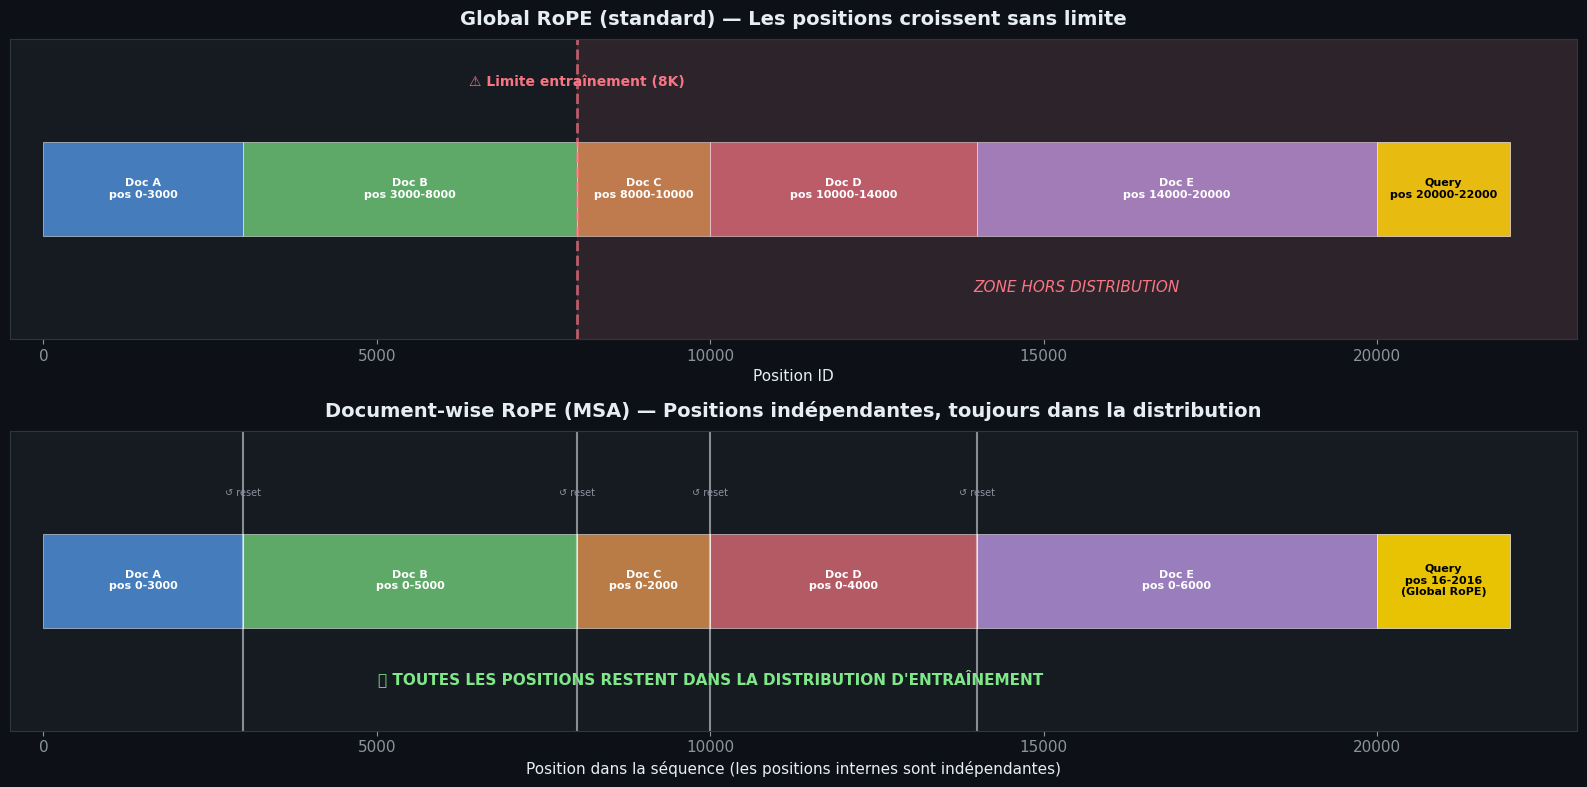

🔑 Avec le RoPE par document, chaque document reste dans la fenêtre vue à l'entraînement.
   C'est ce qui permet d'entraîner sur 64K et d'extrapoler jusqu'à 100M tokens.


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 1]})

# --- Global RoPE (standard) ---
ax = axes[0]
doc_lengths = [3000, 5000, 2000, 4000, 6000]
doc_labels = ['Doc A', 'Doc B', 'Doc C', 'Doc D', 'Doc E']
doc_colors_list = ['#58a6ff', '#7ee787', '#ffa657', '#f97583', '#d2a8ff']

pos = 0
for i, (length, label, color) in enumerate(zip(doc_lengths, doc_labels, doc_colors_list)):
    ax.barh(0, length, left=pos, color=color, alpha=0.7, edgecolor='white', linewidth=0.5, height=0.5)
    ax.text(pos + length/2, 0, f'{label}\npos {pos}-{pos+length}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    pos += length

# Query
ax.barh(0, 2000, left=pos, color='#ffd700', alpha=0.9, edgecolor='white', linewidth=0.5, height=0.5)
ax.text(pos + 1000, 0, f'Query\npos {pos}-{pos+2000}',
        ha='center', va='center', fontsize=8, color='black', fontweight='bold')

ax.set_title('Global RoPE (standard) — Les positions croissent sans limite', pad=10)
ax.set_xlim(-500, pos + 3000)
ax.set_ylim(-0.8, 0.8)
ax.set_yticks([])
ax.set_xlabel('Position ID')

# Zone danger
train_limit = 8000
ax.axvline(x=train_limit, color=COLORS['rag'], linestyle='--', lw=2, alpha=0.7)
ax.text(train_limit, 0.55, '⚠️ Limite entraînement (8K)',
        ha='center', fontsize=10, color=COLORS['rag'], fontweight='bold')
ax.axvspan(train_limit, pos + 3000, alpha=0.1, color=COLORS['rag'])
ax.text((train_limit + pos + 3000)/2, -0.55, 'ZONE HORS DISTRIBUTION',
        ha='center', fontsize=11, color=COLORS['rag'], style='italic')

# --- Document-wise RoPE (MSA) ---
ax = axes[1]
pos = 0
for i, (length, label, color) in enumerate(zip(doc_lengths, doc_labels, doc_colors_list)):
    ax.barh(0, length, left=pos, color=color, alpha=0.7, edgecolor='white', linewidth=0.5, height=0.5)
    ax.text(pos + length/2, 0, f'{label}\npos 0-{length}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    # Separators
    if i < len(doc_lengths) - 1:
        ax.axvline(x=pos + length, color='white', linestyle='-', lw=1.5, alpha=0.5)
        ax.text(pos + length, 0.45, '↺ reset', ha='center', fontsize=7, color=COLORS['muted'])
    pos += length

# Query with global RoPE offset by k
query_start_pos = 16  # k = 16 (top-k)
ax.barh(0, 2000, left=pos, color='#ffd700', alpha=0.9, edgecolor='white', linewidth=0.5, height=0.5)
ax.text(pos + 1000, 0, f'Query\npos {query_start_pos}-{query_start_pos+2000}\n(Global RoPE)',
        ha='center', va='center', fontsize=8, color='black', fontweight='bold')

ax.set_title('Document-wise RoPE (MSA) — Positions indépendantes, toujours dans la distribution', pad=10)
ax.set_xlim(-500, pos + 3000)
ax.set_ylim(-0.8, 0.8)
ax.set_yticks([])
ax.set_xlabel('Position dans la séquence (les positions internes sont indépendantes)')

# Tout est dans la zone safe
ax.axhline(y=-0.55, color=COLORS['linear'], linestyle='-', lw=0, alpha=0)
ax.text(pos/2, -0.55, '✅ TOUTES LES POSITIONS RESTENT DANS LA DISTRIBUTION D\'ENTRAÎNEMENT',
        ha='center', fontsize=11, color=COLORS['linear'], fontweight='bold')

plt.tight_layout()
plt.show()

print("🔑 Avec le RoPE par document, chaque document reste dans la fenêtre vue à l'entraînement.")
print("   C'est ce qui permet d'entraîner sur 64K et d'extrapoler jusqu'à 100M tokens.")


---
## 5. 📦 Compression KV Cache par Mean Pooling

MSA compresse les KV caches par **mean pooling** sur des chunks de taille P=64.
Cela réduit la mémoire et la latence d'un facteur ~64, rendant 100M tokens tenables.


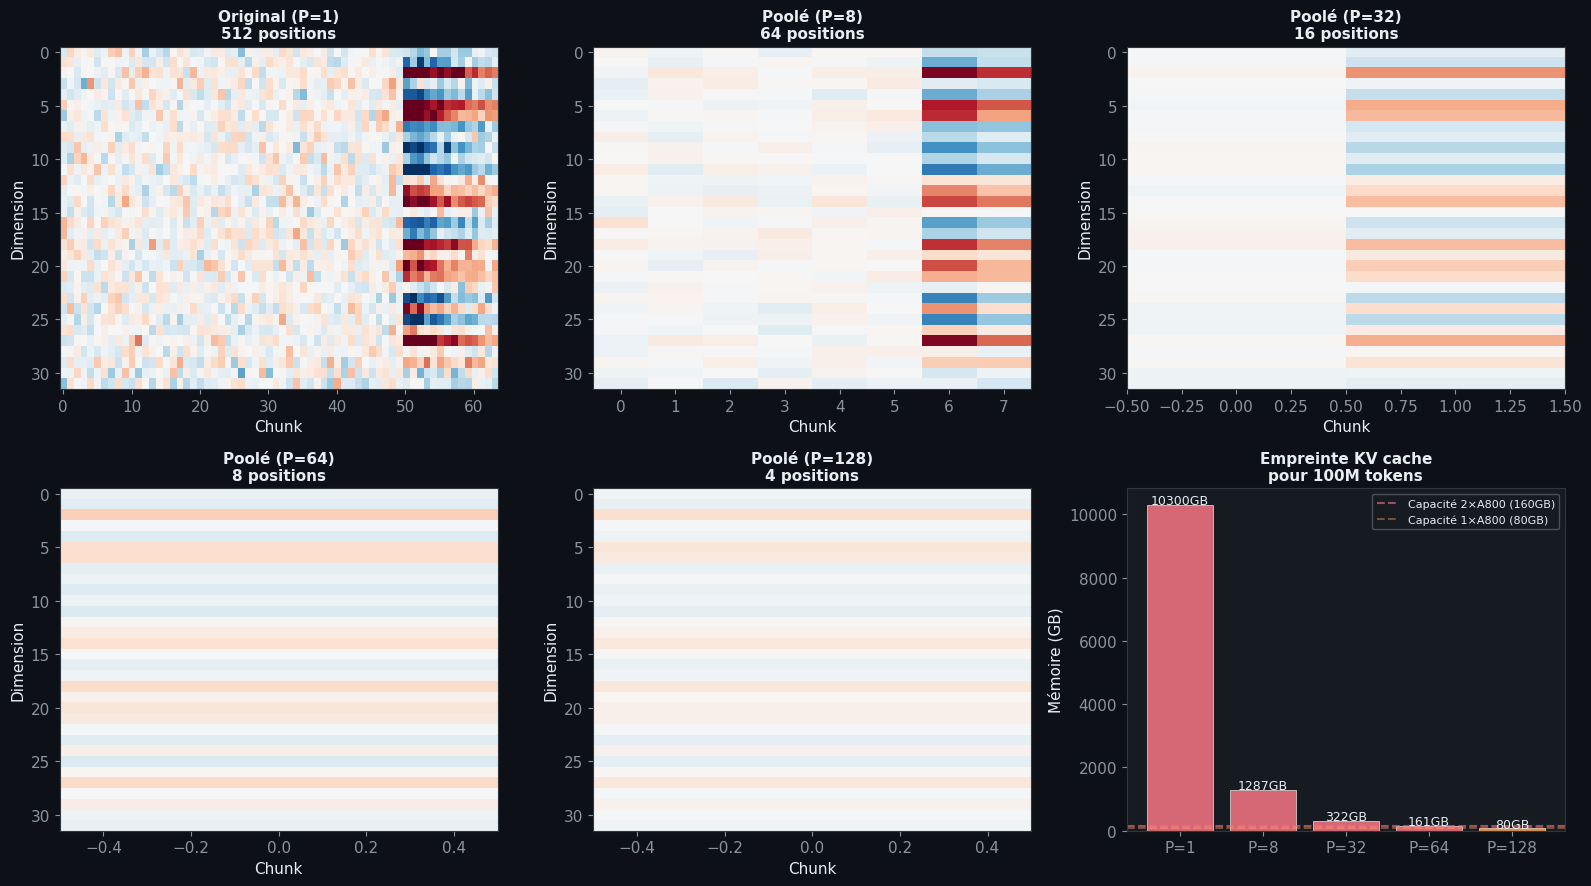

📦 Avec P=64 (choix de MSA), le cache KV pour 100M tokens occupe ~161GB
   vs ~10300GB sans compression — réduction de 64×


In [6]:
# Simulation de compression par mean pooling
np.random.seed(123)

# Signal simulé : séquence de KV avec information structurée
seq_len = 512
dim = 64

# Créer un signal avec des patterns locaux et un "needle" caché
signal = np.random.randn(seq_len, dim) * 0.3
# Ajouter des patterns documentaires
for start in [50, 200, 380]:
    pattern = np.random.randn(dim) * 2.0
    for j in range(30):
        if start + j < seq_len:
            signal[start + j] += pattern * np.exp(-0.1 * j)

# Appliquer mean pooling avec différentes tailles
pool_sizes = [1, 8, 32, 64, 128]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, P in enumerate(pool_sizes):
    ax = axes[idx // 3][idx % 3]

    n_chunks = seq_len // P
    compressed = np.zeros((n_chunks, dim))
    for c in range(n_chunks):
        compressed[c] = signal[c*P:(c+1)*P].mean(axis=0)

    # Visualiser comme heatmap
    if P == 1:
        data = signal[:64, :32]  # sous-section pour lisibilité
        title = f'Original (P=1)\n{seq_len} positions'
    else:
        data = compressed[:max(1, 64//P), :32]
        title = f'Poolé (P={P})\n{n_chunks} positions'

    im = ax.imshow(data.T, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Chunk')
    ax.set_ylabel('Dimension')

# Dernier plot : analyse mémoire
ax = axes[1][2]
tokens_100M = 100_000_000
n_heads = 8
head_dim = 128
n_layers = 18
bytes_per_param = 2  # BF16

memory_gb = []
labels_pool = []
for P in [1, 8, 32, 64, 128]:
    n_chunks = tokens_100M // P
    # K + V + K^R = 3 matrices, chacune [n_chunks, n_heads, head_dim] par couche
    mem = 3 * n_chunks * n_heads * head_dim * n_layers * bytes_per_param / (1024**3)
    memory_gb.append(mem)
    labels_pool.append(f'P={P}')

bar_colors = [COLORS['rag'] if m > 160 else (COLORS['accent'] if m > 80 else COLORS['msa'])
              for m in memory_gb]
bars = ax.bar(labels_pool, memory_gb, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(y=160, color=COLORS['rag'], linestyle='--', alpha=0.6, label='Capacité 2×A800 (160GB)')
ax.axhline(y=80, color=COLORS['accent'], linestyle='--', alpha=0.4, label='Capacité 1×A800 (80GB)')
ax.set_ylabel('Mémoire (GB)')
ax.set_title('Empreinte KV cache\npour 100M tokens', fontsize=11)
ax.legend(fontsize=8, framealpha=0.3)

for bar, val in zip(bars, memory_gb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:.0f}GB', ha='center', fontsize=9, color=COLORS['text'])

plt.tight_layout()
plt.show()

print(f"📦 Avec P=64 (choix de MSA), le cache KV pour 100M tokens occupe ~{memory_gb[3]:.0f}GB")
print(f"   vs ~{memory_gb[0]:.0f}GB sans compression — réduction de {memory_gb[0]/memory_gb[3]:.0f}×")


---
## 6. 🔗 Memory Interleave — Raisonnement multi-hop

Pour les questions nécessitant de chaîner plusieurs documents (ex: *"Quand est né le père d'Erik Watts ?"*),
MSA utilise un mécanisme itératif : il génère des IDs de documents, charge leur contenu,
puis relance la recherche avec le contexte enrichi.


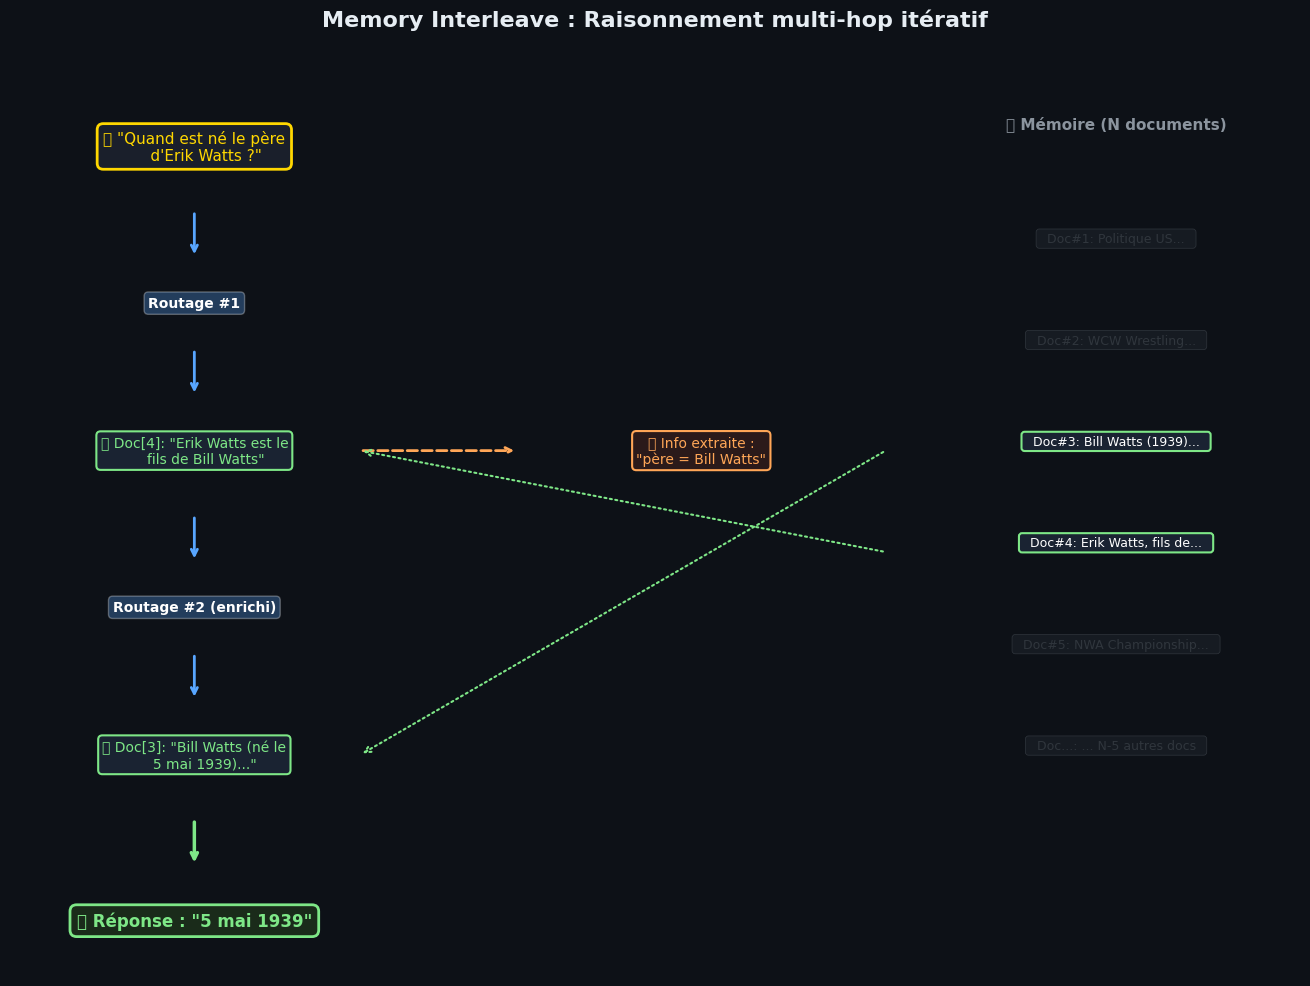

🔗 Memory Interleave permet le raisonnement en chaîne :
   1. Requête → trouve Doc[4] (Erik = fils de Bill)
   2. Contexte enrichi → trouve Doc[3] (Bill né en 1939)
   3. Synthèse → Réponse finale
   L'ablation montre -19.2% sur HotpotQA sans ce mécanisme.


In [7]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Memory Interleave : Raisonnement multi-hop itératif', fontsize=16, pad=20)

# --- Étape 1 : Query initiale ---
rect_props = dict(boxstyle='round,pad=0.4', facecolor='#161b22', edgecolor=COLORS['msa'], linewidth=2)
query_props = dict(boxstyle='round,pad=0.4', facecolor='#1a1f2b', edgecolor='#ffd700', linewidth=2)
doc_props = dict(boxstyle='round,pad=0.3', facecolor='#1a2332', edgecolor=COLORS['linear'], linewidth=1.5)
answer_props = dict(boxstyle='round,pad=0.4', facecolor='#1a2b1a', edgecolor=COLORS['linear'], linewidth=2)

# Query
ax.text(2, 9, '❓ "Quand est né le père\n     d\'Erik Watts ?"',
        fontsize=11, ha='center', va='center', bbox=query_props, color='#ffd700')

# Arrow
ax.annotate('', xy=(2, 7.8), xytext=(2, 8.3),
            arrowprops=dict(arrowstyle='->', color=COLORS['msa'], lw=2))

# Hop 1 : Routing
ax.text(2, 7.3, 'Routage #1', fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['msa'], edgecolor='white', alpha=0.3),
        color='white', fontweight='bold')

ax.annotate('', xy=(2, 6.3), xytext=(2, 6.8),
            arrowprops=dict(arrowstyle='->', color=COLORS['msa'], lw=2))

# Doc retrieved hop 1
ax.text(2, 5.7, '📄 Doc[4]: "Erik Watts est le\n     fils de Bill Watts"',
        fontsize=10, ha='center', va='center', bbox=doc_props, color=COLORS['linear'])

# Info extracted
ax.annotate('', xy=(5.5, 5.7), xytext=(3.8, 5.7),
            arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=2, linestyle='dashed'))
ax.text(7.5, 5.7, '💡 Info extraite :\n"père = Bill Watts"',
        fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#2b1a1a', edgecolor=COLORS['accent'], linewidth=1.5),
        color=COLORS['accent'])

# Arrow down
ax.annotate('', xy=(2, 4.5), xytext=(2, 5.0),
            arrowprops=dict(arrowstyle='->', color=COLORS['msa'], lw=2))

# Hop 2 : New query enriched
ax.text(2, 4.0, 'Routage #2 (enrichi)', fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['msa'], edgecolor='white', alpha=0.3),
        color='white', fontweight='bold')

ax.annotate('', xy=(2, 3.0), xytext=(2, 3.5),
            arrowprops=dict(arrowstyle='->', color=COLORS['msa'], lw=2))

# Doc retrieved hop 2
ax.text(2, 2.4, '📄 Doc[3]: "Bill Watts (né le\n     5 mai 1939)..."',
        fontsize=10, ha='center', va='center', bbox=doc_props, color=COLORS['linear'])

# Arrow to answer
ax.annotate('', xy=(2, 1.2), xytext=(2, 1.7),
            arrowprops=dict(arrowstyle='->', color=COLORS['linear'], lw=2.5))

# Final answer
ax.text(2, 0.6, '✅ Réponse : "5 mai 1939"',
        fontsize=12, ha='center', va='center', bbox=answer_props, color=COLORS['linear'],
        fontweight='bold')

# Memory bank on the right
ax.text(12, 9.2, '🗄️ Mémoire (N documents)', fontsize=11, ha='center',
        color=COLORS['muted'], fontweight='bold')
for i, (doc_id, text, highlight) in enumerate([
    ('#1', 'Politique US...', False),
    ('#2', 'WCW Wrestling...', False),
    ('#3', 'Bill Watts (1939)...', True),
    ('#4', 'Erik Watts, fils de...', True),
    ('#5', 'NWA Championship...', False),
    ('...', '... N-5 autres docs', False),
]):
    y = 8.0 - i * 1.1
    c = COLORS['linear'] if highlight else '#30363d'
    fc = '#1a2332' if highlight else '#161b22'
    ax.text(12, y, f'  Doc{doc_id}: {text}  ',
            fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', facecolor=fc, edgecolor=c, linewidth=1.5 if highlight else 0.5),
            color=c if not highlight else 'white')

# Connecting arrows from memory
ax.annotate('', xy=(3.8, 5.7), xytext=(9.5, 4.6),
            arrowprops=dict(arrowstyle='->', color=COLORS['linear'], lw=1.5, linestyle='dotted'))
ax.annotate('', xy=(3.8, 2.4), xytext=(9.5, 5.7),
            arrowprops=dict(arrowstyle='->', color=COLORS['linear'], lw=1.5, linestyle='dotted'))

plt.tight_layout()
plt.show()

print("🔗 Memory Interleave permet le raisonnement en chaîne :")
print("   1. Requête → trouve Doc[4] (Erik = fils de Bill)")
print("   2. Contexte enrichi → trouve Doc[3] (Bill né en 1939)")
print("   3. Synthèse → Réponse finale")
print("   L'ablation montre -19.2% sur HotpotQA sans ce mécanisme.")


---
## 7. 📈 Reproduction de la courbe de scalabilité

Reproduisons la Figure 1 de l'article : la dégradation du score QA en fonction de la taille du contexte.
MSA montre < 9% de dégradation entre 16K et 100M tokens.


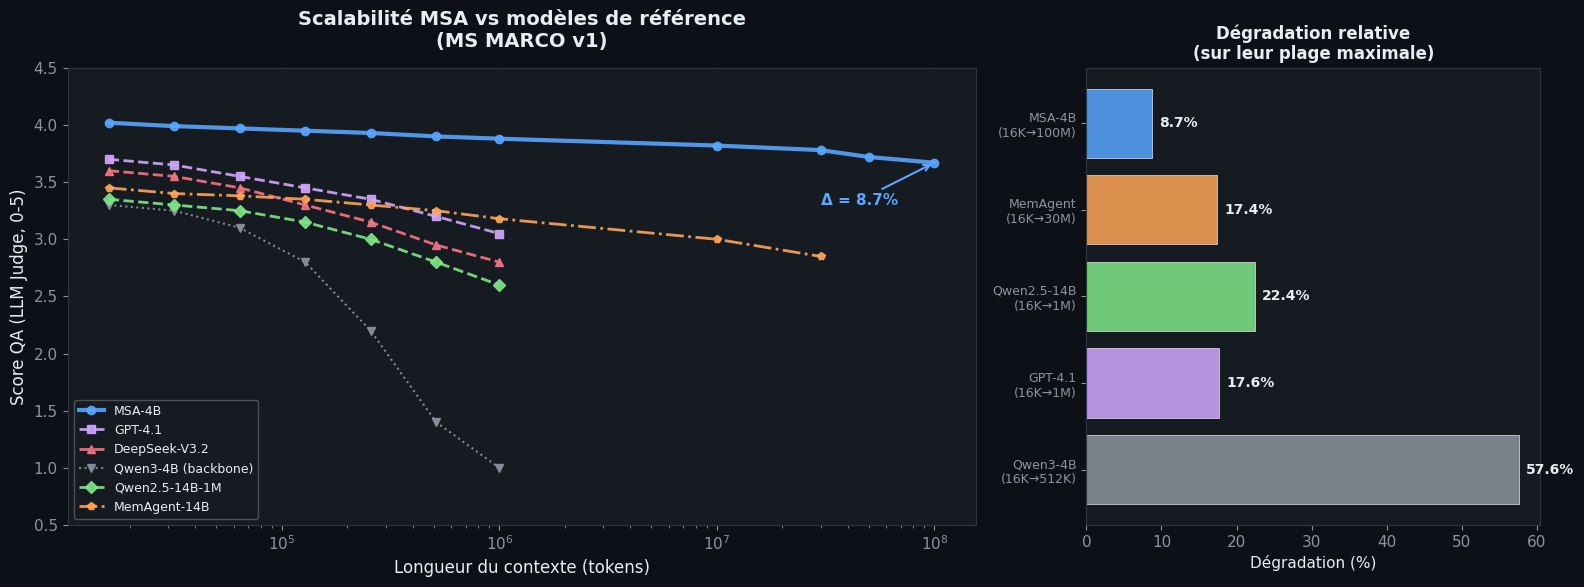

📈 MSA maintient une dégradation de seulement 8.7% sur 4 ordres de grandeur (16K → 100M)
   C'est 3 à 7× moins que les modèles concurrents sur des plages bien plus courtes.


In [8]:
# Données extraites / interpolées de la Figure 1 de l'article
context_lengths = np.array([16e3, 32e3, 64e3, 128e3, 256e3, 512e3, 1e6, 10e6, 30e6, 50e6, 100e6])
context_labels = ['16K', '32K', '64K', '128K', '256K', '512K', '1M', '10M', '30M', '50M', '100M']

# Scores approximatifs des différents modèles (extraits de Figure 1)
models = {
    'MSA-4B': {
        'scores': [4.02, 3.99, 3.97, 3.95, 3.93, 3.90, 3.88, 3.82, 3.78, 3.72, 3.67],
        'color': COLORS['msa'], 'lw': 3, 'marker': 'o', 'ls': '-'
    },
    'GPT-4.1': {
        'scores': [3.70, 3.65, 3.55, 3.45, 3.35, 3.20, 3.05, None, None, None, None],
        'color': '#d2a8ff', 'lw': 2, 'marker': 's', 'ls': '--'
    },
    'DeepSeek-V3.2': {
        'scores': [3.60, 3.55, 3.45, 3.30, 3.15, 2.95, 2.80, None, None, None, None],
        'color': '#f97583', 'lw': 2, 'marker': '^', 'ls': '--'
    },
    'Qwen3-4B (backbone)': {
        'scores': [3.30, 3.25, 3.10, 2.80, 2.20, 1.40, 1.00, None, None, None, None],
        'color': '#8b949e', 'lw': 1.5, 'marker': 'v', 'ls': ':'
    },
    'Qwen2.5-14B-1M': {
        'scores': [3.35, 3.30, 3.25, 3.15, 3.00, 2.80, 2.60, None, None, None, None],
        'color': COLORS['linear'], 'lw': 2, 'marker': 'D', 'ls': '--'
    },
    'MemAgent-14B': {
        'scores': [3.45, 3.40, 3.38, 3.35, 3.30, 3.25, 3.18, 3.00, 2.85, None, None],
        'color': COLORS['accent'], 'lw': 2, 'marker': 'p', 'ls': '-.'
    },
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# --- Main plot ---
for name, data in models.items():
    valid = [(context_lengths[i], data['scores'][i])
             for i in range(len(data['scores'])) if data['scores'][i] is not None]
    x, y = zip(*valid)
    ax1.semilogx(x, y, color=data['color'], lw=data['lw'], marker=data['marker'],
                markersize=6, label=name, linestyle=data['ls'], alpha=0.9)

ax1.set_xlabel('Longueur du contexte (tokens)', fontsize=12)
ax1.set_ylabel('Score QA (LLM Judge, 0-5)', fontsize=12)
ax1.set_title('Scalabilité MSA vs modèles de référence\n(MS MARCO v1)', fontsize=14, pad=15)
ax1.legend(fontsize=9, framealpha=0.3, loc='lower left')
ax1.grid(True, alpha=0.2)
ax1.set_ylim(0.5, 4.5)

# Highlight degradation
ax1.annotate(f'Δ = {((4.02-3.67)/4.02)*100:.1f}%', xy=(1e8, 3.67), xytext=(3e7, 3.3),
            fontsize=11, color=COLORS['msa'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['msa'], lw=1.5))

# --- Degradation comparison ---
degradations = {
    'MSA-4B\n(16K→100M)': 8.7,
    'MemAgent\n(16K→30M)': 17.4,
    'Qwen2.5-14B\n(16K→1M)': 22.4,
    'GPT-4.1\n(16K→1M)': 17.6,
    'Qwen3-4B\n(16K→512K)': 57.6,
}
names = list(degradations.keys())
values = list(degradations.values())
colors_deg = [COLORS['msa'], COLORS['accent'], COLORS['linear'], '#d2a8ff', '#8b949e']

bars = ax2.barh(range(len(names)), values, color=colors_deg, alpha=0.85,
                edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=9)
ax2.set_xlabel('Dégradation (%)', fontsize=11)
ax2.set_title('Dégradation relative\n(sur leur plage maximale)', fontsize=12)
ax2.invert_yaxis()

for bar, val in zip(bars, values):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, color=COLORS['text'], fontweight='bold')

plt.tight_layout()
plt.show()

print("📈 MSA maintient une dégradation de seulement 8.7% sur 4 ordres de grandeur (16K → 100M)")
print("   C'est 3 à 7× moins que les modèles concurrents sur des plages bien plus courtes.")


---
## 8. 🚀 Applications concrètes rendues possibles par MSA

MSA ouvre la voie à des scénarios qui étaient jusqu'ici impraticables pour les LLM.


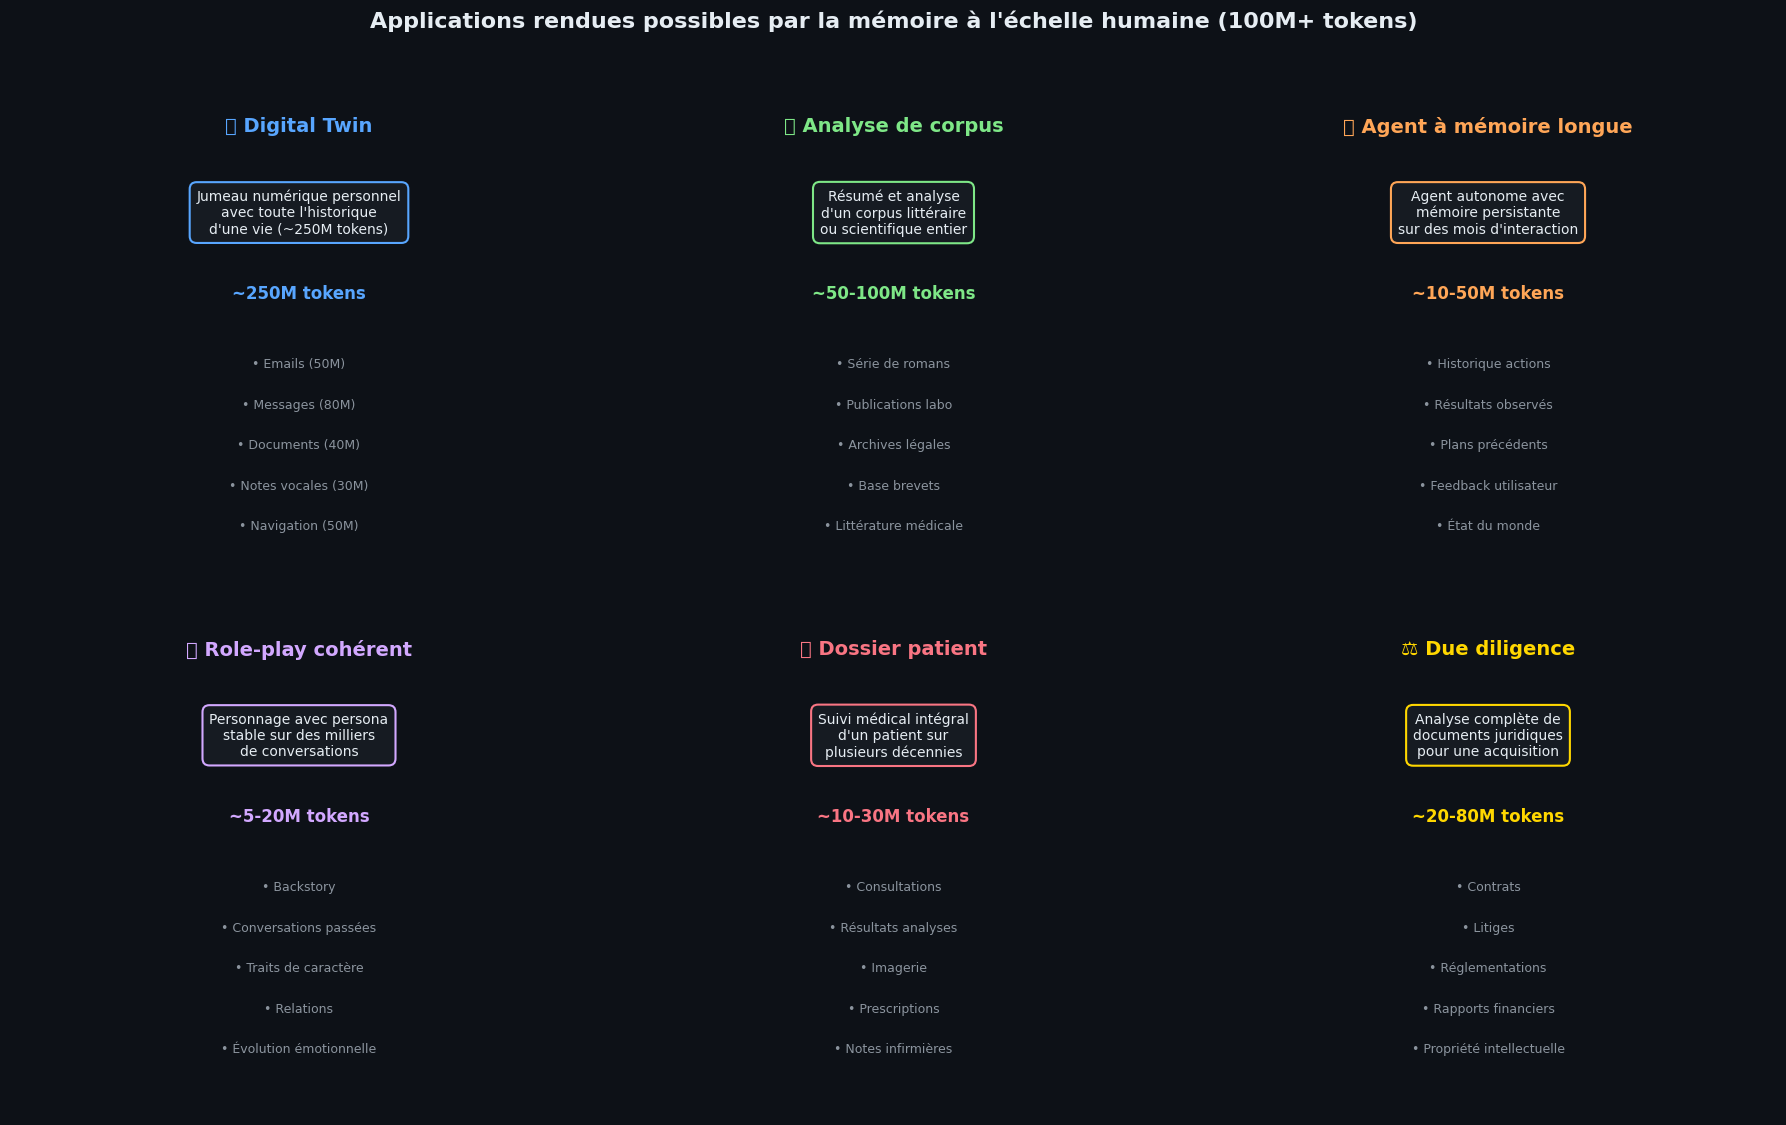

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Applications rendues possibles par la mémoire à l\'échelle humaine (100M+ tokens)',
             fontsize=16, fontweight='bold', y=1.02)

applications = [
    {
        'title': '🧬 Digital Twin',
        'desc': 'Jumeau numérique personnel\navec toute l\'historique\nd\'une vie (~250M tokens)',
        'tokens': '250M',
        'sources': ['Emails (50M)', 'Messages (80M)', 'Documents (40M)',
                   'Notes vocales (30M)', 'Navigation (50M)'],
        'color': COLORS['msa']
    },
    {
        'title': '📚 Analyse de corpus',
        'desc': 'Résumé et analyse\nd\'un corpus littéraire\nou scientifique entier',
        'tokens': '50-100M',
        'sources': ['Série de romans', 'Publications labo', 'Archives légales',
                   'Base brevets', 'Littérature médicale'],
        'color': COLORS['linear']
    },
    {
        'title': '🤖 Agent à mémoire longue',
        'desc': 'Agent autonome avec\nmémoire persistante\nsur des mois d\'interaction',
        'tokens': '10-50M',
        'sources': ['Historique actions', 'Résultats observés', 'Plans précédents',
                   'Feedback utilisateur', 'État du monde'],
        'color': COLORS['accent']
    },
    {
        'title': '🎭 Role-play cohérent',
        'desc': 'Personnage avec persona\nstable sur des milliers\nde conversations',
        'tokens': '5-20M',
        'sources': ['Backstory', 'Conversations passées', 'Traits de caractère',
                   'Relations', 'Évolution émotionnelle'],
        'color': '#d2a8ff'
    },
    {
        'title': '🏥 Dossier patient',
        'desc': 'Suivi médical intégral\nd\'un patient sur\nplusieurs décennies',
        'tokens': '10-30M',
        'sources': ['Consultations', 'Résultats analyses', 'Imagerie', 'Prescriptions',
                   'Notes infirmières'],
        'color': COLORS['rag']
    },
    {
        'title': '⚖️ Due diligence',
        'desc': 'Analyse complète de\ndocuments juridiques\npour une acquisition',
        'tokens': '20-80M',
        'sources': ['Contrats', 'Litiges', 'Réglementations', 'Rapports financiers',
                   'Propriété intellectuelle'],
        'color': '#ffd700'
    },
]

for idx, app in enumerate(applications):
    ax = axes[idx // 3][idx % 3]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Title
    ax.text(5, 9.2, app['title'], fontsize=14, ha='center', va='center',
            fontweight='bold', color=app['color'])

    # Description box
    ax.text(5, 7.5, app['desc'], fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#161b22', edgecolor=app['color'],
                     linewidth=1.5), color=COLORS['text'])

    # Token count
    ax.text(5, 5.8, f'~{app["tokens"]} tokens', fontsize=12, ha='center',
            color=app['color'], fontweight='bold')

    # Sources
    for i, src in enumerate(app['sources']):
        y = 4.5 - i * 0.8
        ax.text(5, y, f'• {src}', fontsize=9, ha='center', va='center',
                color=COLORS['muted'])

plt.tight_layout()
plt.show()


---
## 9. 📊 Résultats comparatifs : MSA vs RAG vs Long-context LLMs

Synthèse des performances sur les 9 benchmarks QA et le test NIAH.


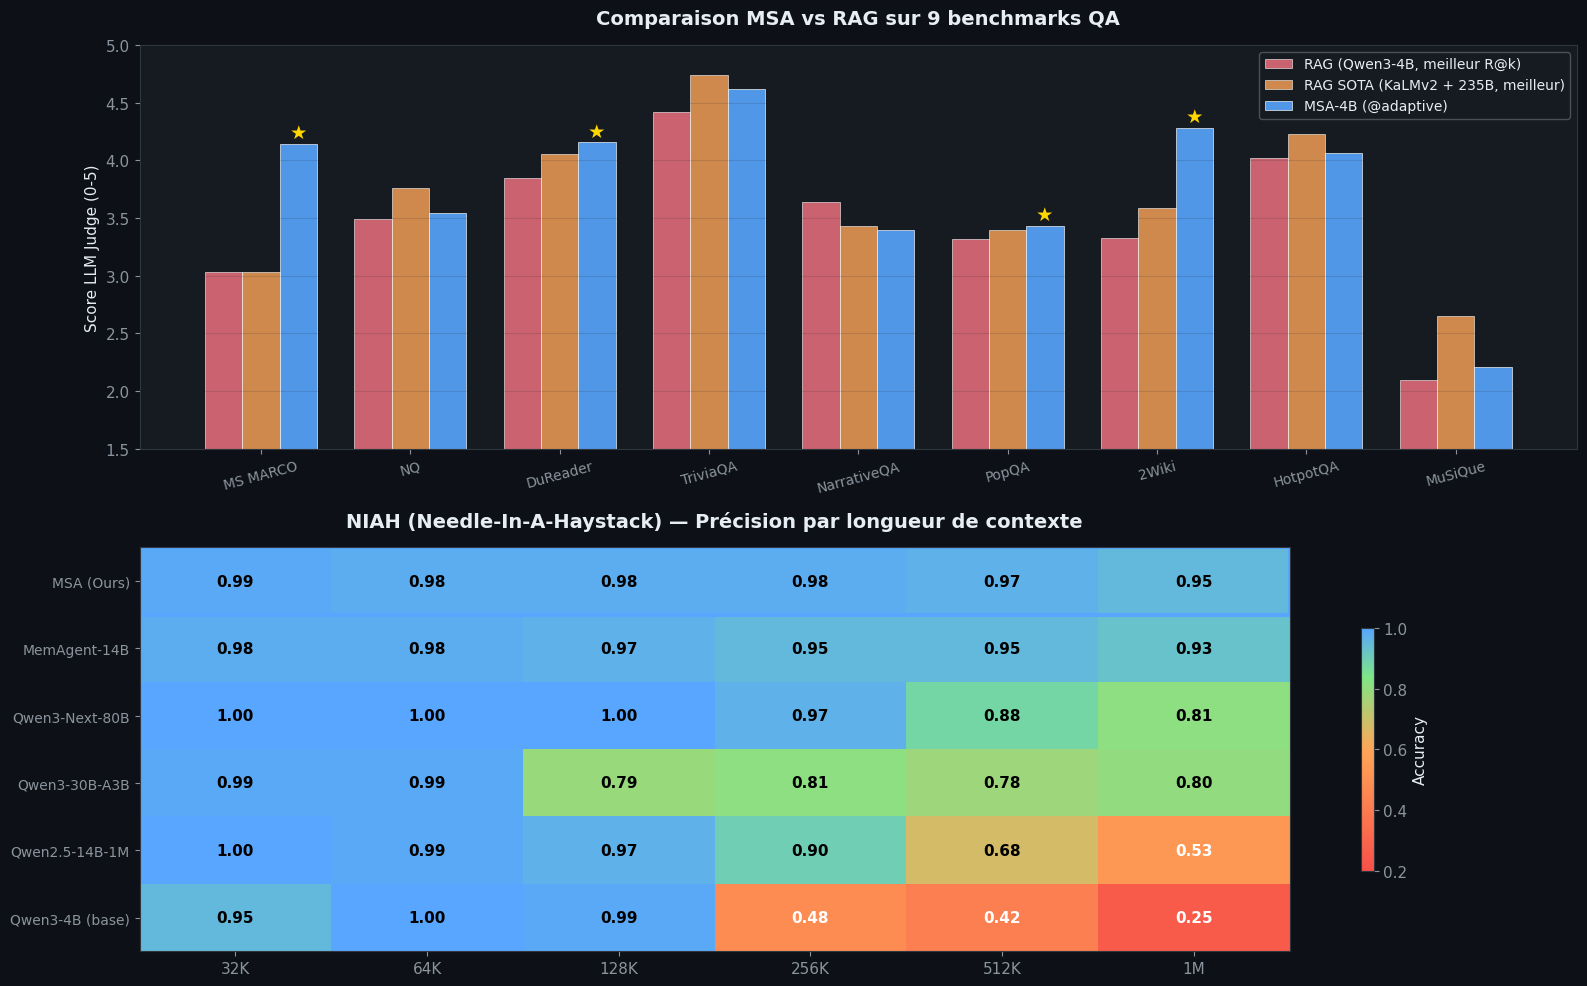

★ = MSA bat les deux types de RAG sur ce dataset

📊 MSA-4B gagne sur 4/9 datasets,
   y compris contre des RAG utilisant des modèles 60× plus gros (Qwen3-235B)


In [10]:
# Données des benchmarks (Table 2 et Table 3)
datasets = ['MS MARCO', 'NQ', 'DuReader', 'TriviaQA', 'NarrativeQA',
            'PopQA', '2Wiki', 'HotpotQA', 'MuSiQue']

msa_scores = [4.141, 3.545, 4.155, 4.621, 3.395, 3.433, 4.280, 4.061, 2.211]
rag_same_best = [3.032, 3.494, 3.848, 4.414, 3.638, 3.315, 3.330, 4.022, 2.095]  # best across R@k for same backbone
rag_sota_best = [3.028, 3.756, 4.051, 4.740, 3.427, 3.396, 3.583, 4.225, 2.647]  # best across all SOTA configs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- Radar-style bar comparison ---
x = np.arange(len(datasets))
width = 0.25

bars1 = ax1.bar(x - width, rag_same_best, width, label='RAG (Qwen3-4B, meilleur R@k)',
               color=COLORS['rag'], alpha=0.8, edgecolor='white', linewidth=0.5)
bars2 = ax1.bar(x, rag_sota_best, width, label='RAG SOTA (KaLMv2 + 235B, meilleur)',
               color=COLORS['accent'], alpha=0.8, edgecolor='white', linewidth=0.5)
bars3 = ax1.bar(x + width, msa_scores, width, label='MSA-4B (@adaptive)',
               color=COLORS['msa'], alpha=0.9, edgecolor='white', linewidth=0.5)

ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=10, rotation=15)
ax1.set_ylabel('Score LLM Judge (0-5)')
ax1.set_title('Comparaison MSA vs RAG sur 9 benchmarks QA', fontsize=14, pad=15)
ax1.legend(fontsize=10, framealpha=0.3)
ax1.grid(True, alpha=0.15, axis='y')
ax1.set_ylim(1.5, 5.0)

# Highlight wins
for i in range(len(datasets)):
    if msa_scores[i] >= max(rag_same_best[i], rag_sota_best[i]):
        ax1.text(x[i] + width, msa_scores[i] + 0.05, '★', fontsize=14,
                ha='center', color='#ffd700')

# --- NIAH heatmap ---
niah_lengths = ['32K', '64K', '128K', '256K', '512K', '1M']
niah_models = ['MSA (Ours)', 'MemAgent-14B', 'Qwen3-Next-80B', 'Qwen3-30B-A3B',
               'Qwen2.5-14B-1M', 'Qwen3-4B (base)']
niah_data = np.array([
    [0.99, 0.98, 0.98, 0.98, 0.97, 0.95],  # MSA
    [0.98, 0.98, 0.97, 0.95, 0.95, 0.93],  # MemAgent
    [1.00, 1.00, 1.00, 0.97, 0.88, 0.81],  # Qwen3-Next-80B
    [0.99, 0.99, 0.79, 0.81, 0.78, 0.80],  # Qwen3-30B
    [1.00, 0.99, 0.97, 0.90, 0.68, 0.53],  # Qwen2.5-14B
    [0.95, 1.00, 0.99, 0.48, 0.42, 0.25],  # Qwen3-4B
])

cmap = LinearSegmentedColormap.from_list('custom',
    [(0, '#f85149'), (0.5, '#ffa657'), (0.8, '#7ee787'), (1.0, '#58a6ff')])
im = ax2.imshow(niah_data, cmap=cmap, aspect='auto', vmin=0.2, vmax=1.0)

for i in range(len(niah_models)):
    for j in range(len(niah_lengths)):
        val = niah_data[i, j]
        text_color = 'white' if val < 0.6 else 'black'
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)

ax2.set_xticks(range(len(niah_lengths)))
ax2.set_xticklabels(niah_lengths, fontsize=11)
ax2.set_yticks(range(len(niah_models)))
ax2.set_yticklabels(niah_models, fontsize=10)
ax2.set_title('NIAH (Needle-In-A-Haystack) — Précision par longueur de contexte', fontsize=14, pad=15)

# Highlight MSA row
ax2.add_patch(plt.Rectangle((-0.5, -0.5), len(niah_lengths), 1,
              fill=False, edgecolor=COLORS['msa'], linewidth=3))

plt.colorbar(im, ax=ax2, shrink=0.6, label='Accuracy')

plt.tight_layout()
plt.show()

print("★ = MSA bat les deux types de RAG sur ce dataset")
print(f"\n📊 MSA-4B gagne sur {sum(1 for i in range(len(datasets)) if msa_scores[i] >= max(rag_same_best[i], rag_sota_best[i]))}/9 datasets,")
print(f"   y compris contre des RAG utilisant des modèles 60× plus gros (Qwen3-235B)")


---
## 10. 🔬 Ablation : contribution de chaque composant

L'étude d'ablation révèle l'importance relative de chaque innovation.


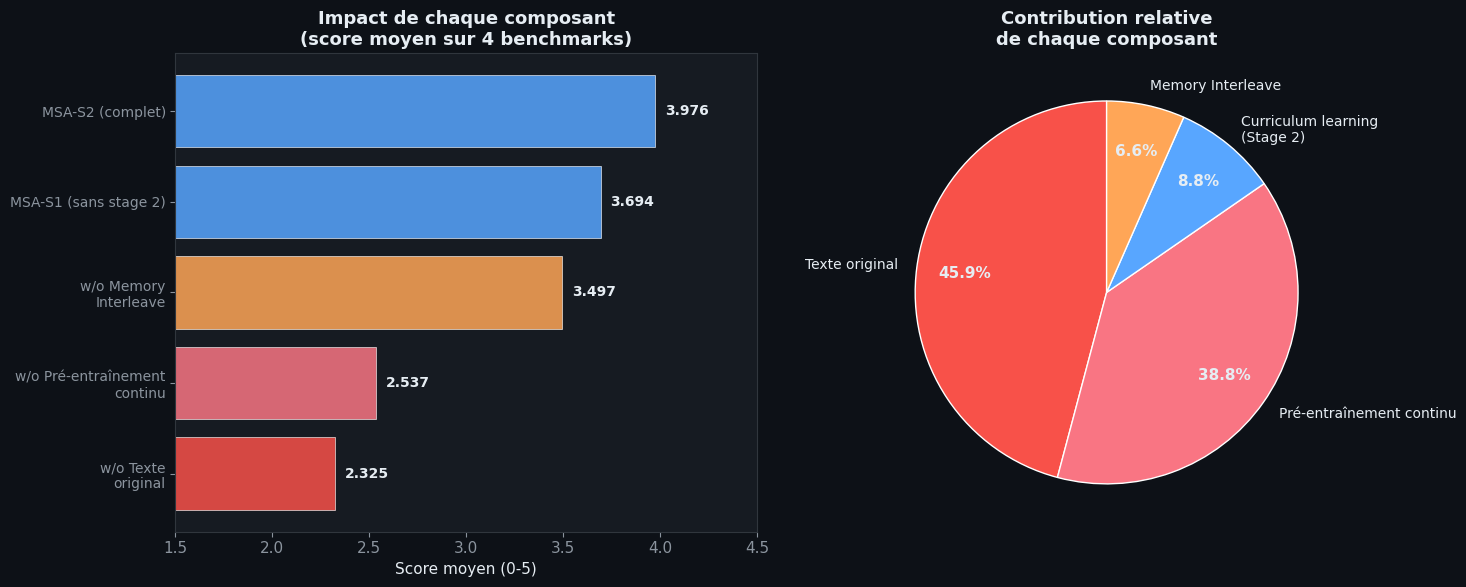

🔬 Enseignements clés de l'ablation :
   • Le texte original est critique (-37.1%) : les IDs ne suffisent pas
   • Le pré-entraînement continu est fondamental (-31.3%) : il ancre le routage
   • Memory Interleave apporte un gain ciblé (-5.3%) sur le multi-hop


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Ablation data
components = ['MSA-S2 (complet)', 'MSA-S1 (sans stage 2)', 'w/o Memory\nInterleave',
              'w/o Pré-entraînement\ncontinu', 'w/o Texte\noriginal']
avg_scores = [3.976, 3.694, 3.497, 2.537, 2.325]
colors_abl = [COLORS['msa'], '#58a6ff99', COLORS['accent'], COLORS['rag'], '#f8514999']

bars = ax1.barh(range(len(components)), avg_scores, color=colors_abl,
                alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(components)))
ax1.set_yticklabels(components, fontsize=10)
ax1.set_xlabel('Score moyen (0-5)', fontsize=11)
ax1.set_title('Impact de chaque composant\n(score moyen sur 4 benchmarks)', fontsize=13)
ax1.invert_yaxis()
ax1.set_xlim(1.5, 4.5)

for bar, val in zip(bars, avg_scores):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, color=COLORS['text'], fontweight='bold')

# Impact relatif
impacts = {
    'Texte original': (3.694 - 2.325) / 3.694 * 100,
    'Pré-entraînement continu': (3.694 - 2.537) / 3.694 * 100,
    'Curriculum learning\n(Stage 2)': (3.976 - 3.694) / 3.976 * 100,
    'Memory Interleave': (3.694 - 3.497) / 3.694 * 100,
}
names_imp = list(impacts.keys())
values_imp = list(impacts.values())
colors_imp = ['#f85149', COLORS['rag'], COLORS['msa'], COLORS['accent']]

wedges, texts, autotexts = ax2.pie(values_imp, labels=names_imp, autopct='%1.1f%%',
                                     colors=colors_imp, textprops={'color': COLORS['text'], 'fontsize': 10},
                                     pctdistance=0.75, startangle=90, wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax2.set_title('Contribution relative\nde chaque composant', fontsize=13)

plt.tight_layout()
plt.show()

print("🔬 Enseignements clés de l'ablation :")
print(f"   • Le texte original est critique (-{impacts['Texte original']:.1f}%) : les IDs ne suffisent pas")
print(f"   • Le pré-entraînement continu est fondamental (-{impacts['Pré-entraînement continu']:.1f}%) : il ancre le routage")
print(f"   • Memory Interleave apporte un gain ciblé (-{impacts['Memory Interleave']:.1f}%) sur le multi-hop")


---
## 11. 🏗️ Synthèse : les 3 étapes de l'inférence MSA

Vue d'ensemble du pipeline complet, de l'encodage offline à la génération sparse.


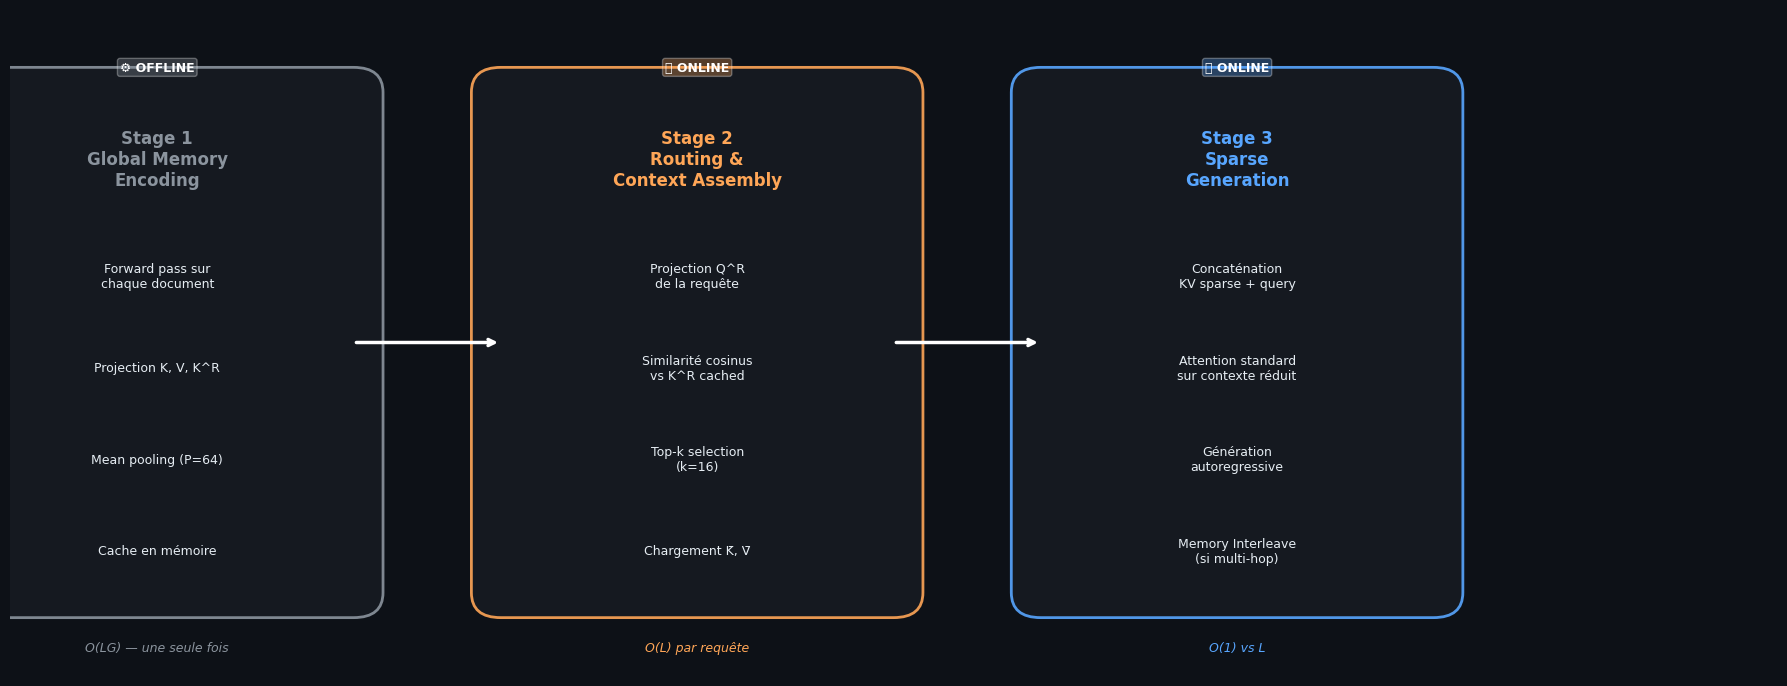

🏗️ L'architecture en 3 stages découple le coût fixe (encoding) du coût par requête (routing + génération).
   Cela amortit le pré-traitement sur un nombre arbitraire de requêtes.


In [12]:
fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 8)
ax.axis('off')

# Stage boxes
stages = [
    (1.5, 'Stage 1\nGlobal Memory\nEncoding', '⚙️ OFFLINE', COLORS['muted'],
     ['Forward pass sur\nchaque document', 'Projection K, V, K^R', 'Mean pooling (P=64)', 'Cache en mémoire']),
    (7, 'Stage 2\nRouting &\nContext Assembly', '🔍 ONLINE', COLORS['accent'],
     ['Projection Q^R\nde la requête', 'Similarité cosinus\nvs K^R cached', 'Top-k selection\n(k=16)', 'Chargement K̄, V̄']),
    (12.5, 'Stage 3\nSparse\nGeneration', '🎯 ONLINE', COLORS['msa'],
     ['Concaténation\nKV sparse + query', 'Attention standard\nsur contexte réduit', 'Génération\nautoregressive', 'Memory Interleave\n(si multi-hop)']),
]

for x_center, title, badge, color, steps in stages:
    # Main box
    rect = mpatches.FancyBboxPatch((x_center - 2, 1), 4, 6,
                                    boxstyle='round,pad=0.3',
                                    facecolor='#161b22', edgecolor=color,
                                    linewidth=2, alpha=0.9)
    ax.add_patch(rect)

    # Badge
    ax.text(x_center, 7.3, badge, fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, edgecolor='white', alpha=0.3),
            color='white', fontweight='bold')

    # Title
    ax.text(x_center, 6.2, title, fontsize=12, ha='center', va='center',
            color=color, fontweight='bold')

    # Steps
    for i, step in enumerate(steps):
        ax.text(x_center, 4.8 - i * 1.1, step, fontsize=9, ha='center', va='center',
                color=COLORS['text'])

# Arrows between stages
for x1, x2 in [(3.5, 5), (9, 10.5)]:
    ax.annotate('', xy=(x2, 4), xytext=(x1, 4),
                arrowprops=dict(arrowstyle='->', color='white', lw=2.5))

# Complexity labels
ax.text(1.5, 0.3, 'O(LG) — une seule fois', fontsize=9, ha='center',
        color=COLORS['muted'], style='italic')
ax.text(7, 0.3, 'O(L) par requête', fontsize=9, ha='center',
        color=COLORS['accent'], style='italic')
ax.text(12.5, 0.3, 'O(1) vs L', fontsize=9, ha='center',
        color=COLORS['msa'], style='italic')

plt.tight_layout()
plt.show()

print("🏗️ L'architecture en 3 stages découple le coût fixe (encoding) du coût par requête (routing + génération).")
print("   Cela amortit le pré-traitement sur un nombre arbitraire de requêtes.")


---
## 📝 Synthèse

Ce notebook a illustré les mécanismes clés de **Memory Sparse Attention** :

| Innovation | Rôle | Impact |
|---|---|---|
| **Routage Top-k sparse** | Sélection des documents pertinents | Complexité linéaire O(L) |
| **Document-wise RoPE** | Positions indépendantes par document | Extrapolation 64K → 100M |
| **Mean pooling KV** | Compression du cache par ×64 | 100M tokens sur 2×A800 |
| **Memory Interleave** | Raisonnement multi-hop itératif | +19% sur HotpotQA |
| **Perte auxiliaire L_aux** | Supervision contrastive du routage | +31% de précision |

### Points forts
- **< 9% de dégradation** de 16K à 100M tokens
- **Surpasse RAG** avec des modèles 60× plus petits (4B vs 235B)
- **End-to-end trainable** : pas de pipeline de récupération découplé

### Limites identifiées
- Évaluation limitée au QA (pas de génération longue, role-play, etc.)
- Compression par mean pooling potentiellement destructive pour les signaux fins
- Pas de mise à jour incrémentale de la mémoire
- Latence multi-hop non quantifiée

---
*Notebook généré pour illustrer les concepts de MSA (Chen et al., 2025)*
